"The multi-armed bandit (MAB) problem is a reinforcement learning scenario where an agent must choose between multiple options (arms) to maximize cumulative rewards, balancing exploration (trying new options) and exploitation (using known, high-reward options). It models decisions under uncertainty, such as medical trials, ad optimization, or portfolio management, where each action has an unknown,, probability distribution of success."

https://en.wikipedia.org/wiki/Multi-armed_bandit

# Modeling goal

-Predictive analytics eg predicting 'session end completed' based on notification decision (template) and context

Business insight?
- Insights from MAB perspective?
- Template effectiveness modeling using different modeling techniques? (eg logistic, tabPFN, Random Forest, neural nets)
--> eg outcome of analyses: "we can increase engagement by ....% by perosnalizing template selection by language etc"

## Mount & Extract

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = "/content/drive/MyDrive/Datathon"
WORK = "/content/work"

import os
os.makedirs(WORK, exist_ok=True)

# Extract only if empty
import glob
import subprocess

tar_files = glob.glob(f"{PROJECT}/train-part-*.tar.gz")

for f in tar_files:
    print("Extracting:", f)
    subprocess.run(["tar", "-xzf", f, "-C", WORK])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting: /content/drive/MyDrive/Datathon/train-part-3.tar.gz
Extracting: /content/drive/MyDrive/Datathon/train-part-2.tar.gz
Extracting: /content/drive/MyDrive/Datathon/train-part-1.tar.gz


In [2]:
!ls {WORK}

train-part-1  train-part-2  train-part-3


tar.gz contains parquet files. As per the readme "The files for each part should be unzipped to a single direcctory and read as a single dataset."

## Connect DuckDB

In [3]:
!pip install -q duckdb

In [4]:

import duckdb

con = duckdb.connect()

train_path = "/content/work/**/*.parquet"

con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{train_path}')
""").fetchone()

(87665839,)

In [5]:


con.execute(f"""
CREATE OR REPLACE VIEW train AS
SELECT * FROM read_parquet('{train_path}');
""")

# EDA Nerissa


**FIRST EXPLORATION**

In [6]:
con.execute("DESCRIBE train").df()

,column_name,column_type,null,key,default,extra
0,datetime,DOUBLE,YES,None,None,None
1,ui_language,VARCHAR,YES,None,None,None
2,eligible_templates,VARCHAR[],YES,None,None,None
3,history,"STRUCT(""template"" VARCHAR, n_days FLOAT)[]",YES,None,None,None
4,selected_template,VARCHAR,YES,None,None,None
5,session_end_completed,BOOLEAN,YES,None,None,None


In [7]:
con.execute("SELECT * FROM train LIMIT 15").df()

,datetime,ui_language,eligible_templates,history,selected_template,session_end_completed
0,0.153461,en,"[G, E, B, A, K, H, J, L, F, D]","[{'template': 'A', 'n_days': 28.19564819335937...",B,False
1,2.827303,es,"[G, E, B, A, K, H, J, L, F, D]","[{'template': 'A', 'n_days': 29.836181640625},...",A,True
2,2.792662,en,"[G, E, B, K, H, J, L, F, D]","[{'template': 'G', 'n_days': 8.197543144226074...",J,True
3,4.904225,en,"[G, E, B, A, K, H, J, L, F, D]","[{'template': 'B', 'n_days': 29.00238037109375...",L,False
4,9.538715,en,"[K, H, G, E, B, J, L, F, D, A]","[{'template': 'B', 'n_days': 27.97145843505859...",B,True
5,9.763287,en,"[K, H, G, E, B, J, L, F, D, A]","[{'template': 'B', 'n_days': 29.01321411132812...",F,False
6,9.301667,en,"[K, H, G, E, B, J, L, F, D, A]","[{'template': 'C', 'n_days': 29.00682830810547...",E,False
7,6.519630,en,"[G, E, B, K, H, J, L, F, D]","[{'template': 'B', 'n_days': 29.04664611816406...",F,False
8,9.735660,en,"[K, H, G, E, B, J, L, F, D]","[{'template': 'E', 'n_days': 29.99932861328125...",E,False
9,8.220833,en,"[G, E, B, A, K, H, J, L, F, D]","[{'template': 'D', 'n_days': 5.13071870803833}...",G,False



**Phase 1: Baseline & Global Metrics**


Total Notifications: 87,665,839
Positive Interactions (Success): 12,608,610.0
Negative Interactions (Ignored): 75,057,229.0
Global Reward Rate: 14.38%


/tmp/ipython-input-2263490271.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette=['#ff9999','#66b3ff'])


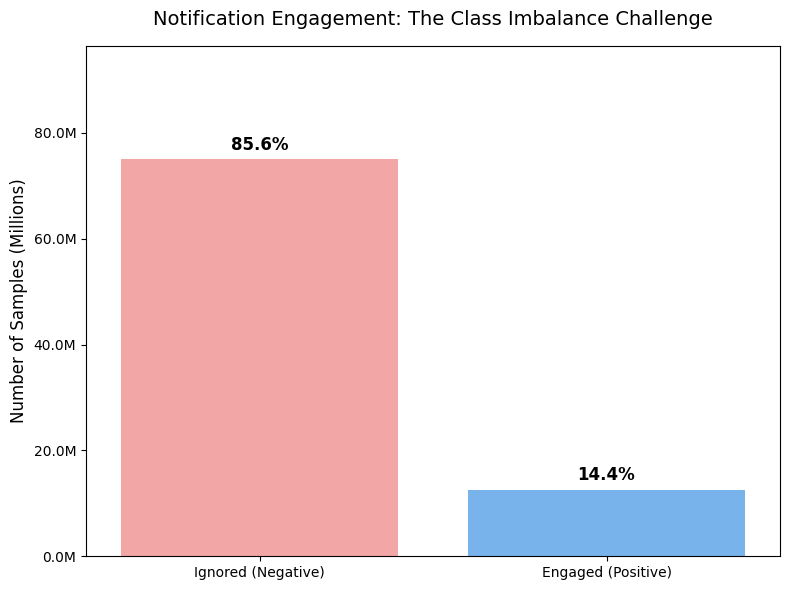

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the exact counts and global reward rate using DuckDB
# We use the 'train' view created in the initial setup
baseline_stats = con.execute("""
    SELECT
        COUNT(*) AS total_notifications,
        SUM(CASE WHEN session_end_completed THEN 1 ELSE 0 END) AS positive_samples,
        SUM(CASE WHEN NOT session_end_completed THEN 1 ELSE 0 END) AS negative_samples,
        AVG(CASE WHEN session_end_completed THEN 1 ELSE 0 END) AS global_reward_rate
    FROM train
""").df()

# Extract values for easier use
total = baseline_stats['total_notifications'][0]
pos = baseline_stats['positive_samples'][0]
neg = baseline_stats['negative_samples'][0]
rate = baseline_stats['global_reward_rate'][0]

print(f"Total Notifications: {total:,}")
print(f"Positive Interactions (Success): {pos:,}")
print(f"Negative Interactions (Ignored): {neg:,}")
print(f"Global Reward Rate: {rate:.2%}")

# 2. Visualize the Class Imbalance
labels = ['Ignored (Negative)', 'Engaged (Positive)']
counts = [neg, pos]

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=counts, palette=['#ff9999','#66b3ff'])

# Add labels and formatting
plt.title('Notification Engagement: The Class Imbalance Challenge', fontsize=14, pad=15)
plt.ylabel('Number of Samples (Millions)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Add percentage text on top of bars
plt.text(0, neg + (total*0.02), f'{(neg/total):.1%}', ha='center', fontsize=12, fontweight='bold')
plt.text(1, pos + (total*0.02), f'{(pos/total):.1%}', ha='center', fontsize=12, fontweight='bold')

plt.ylim(0, total * 1.1) # Leave space for labels
plt.tight_layout()
plt.show()

**Phase 2: Contextual Features**

**2.1 Language Distribution: Mapping the Volume**

/tmp/ipython-input-760478789.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_lang_volume, x='ui_language', y='n_notifications', palette='viridis')


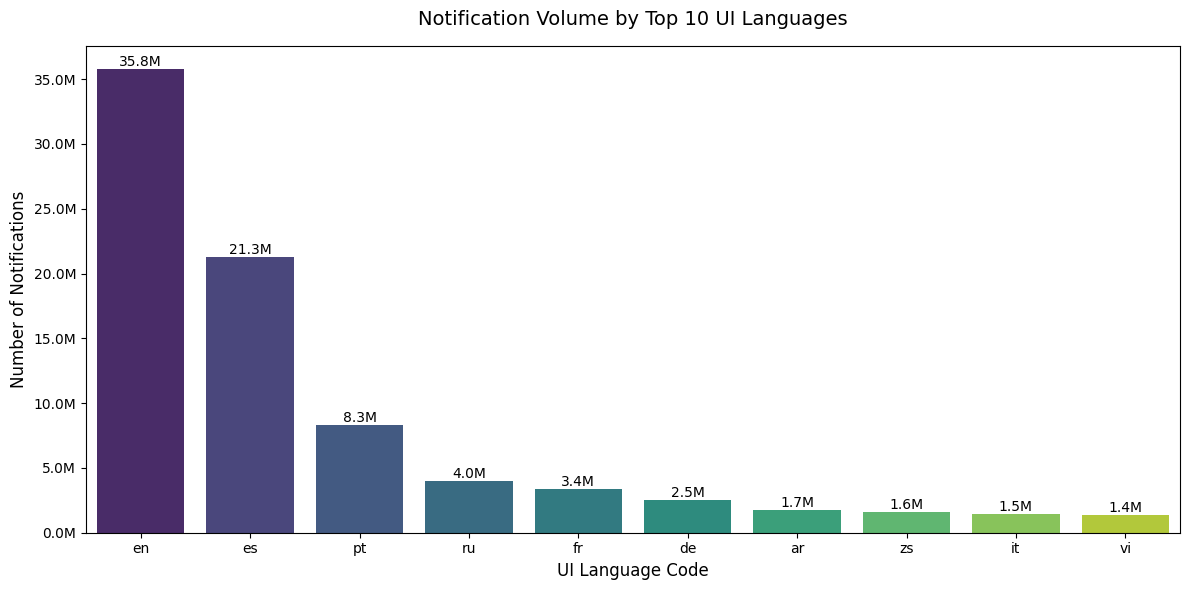

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Query notification volume by language
# We filter for the top 10 languages to keep the visualization clean
df_lang_volume = con.execute("""
    SELECT
        ui_language,
        COUNT(*) as n_notifications
    FROM train
    GROUP BY 1
    ORDER BY n_notifications DESC
    LIMIT 10
""").df()

# 2. Visualize Language Distribution
plt.figure(figsize=(12, 6))
sns.barplot(data=df_lang_volume, x='ui_language', y='n_notifications', palette='viridis')

plt.title('Notification Volume by Top 10 UI Languages', fontsize=14, pad=15)
plt.xlabel('UI Language Code', fontsize=12)
plt.ylabel('Number of Notifications', fontsize=12)

# Format y-axis to show millions
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Add exact counts on top of bars
for i, row in df_lang_volume.iterrows():
    plt.text(i, row.n_notifications, f'{row.n_notifications/1e6:.1f}M', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**2.2 Language vs. Template Affinity: The Heatmap**

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

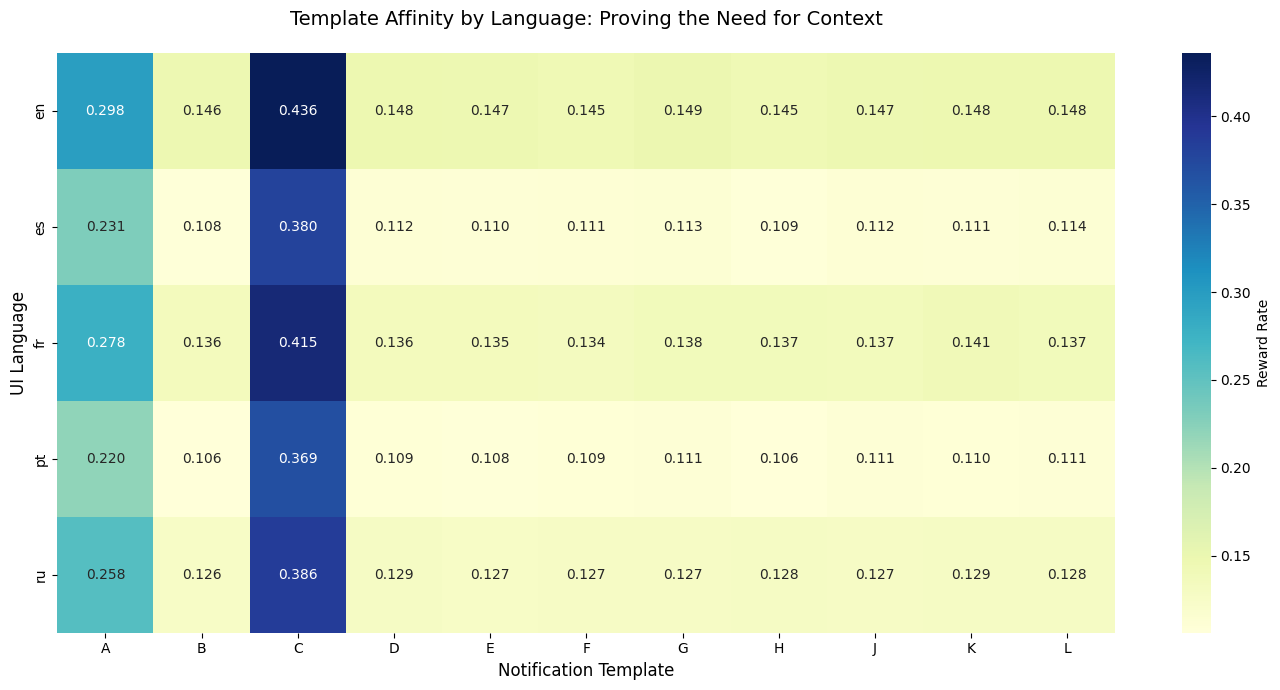

In [10]:
# 1. Query Reward Rate by (Language + Template)
# We focus on the top 5 languages and ensure we have enough samples per pair
df_affinity = con.execute("""
    SELECT
        ui_language,
        selected_template,
        AVG(CASE WHEN session_end_completed THEN 1 ELSE 0 END) AS reward_rate,
        COUNT(*) as n_sends
    FROM train
    WHERE ui_language IN ('en', 'es', 'pt', 'ru', 'fr')
    GROUP BY 1, 2
    HAVING n_sends > 10000 -- Ensure statistical significance
""").df()

# 2. Reshape (pivot) for the heatmap: Rows = Languages, Columns = Templates
pivot_affinity = df_affinity.pivot(index='ui_language', columns='selected_template', values='reward_rate')

# 3. Visualize the Affinity Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(pivot_affinity, annot=True, cmap='YlGnBu', fmt='.3f', cbar_kws={'label': 'Reward Rate'})

plt.title('Template Affinity by Language: Proving the Need for Context', fontsize=14, pad=20)
plt.xlabel('Notification Template', fontsize=12)
plt.ylabel('UI Language', fontsize=12)
plt.tight_layout()
plt.show()

**Phase 3: Temporal Features (The "When")**

**3.1 Correcting for Local Time (CET Example)**

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

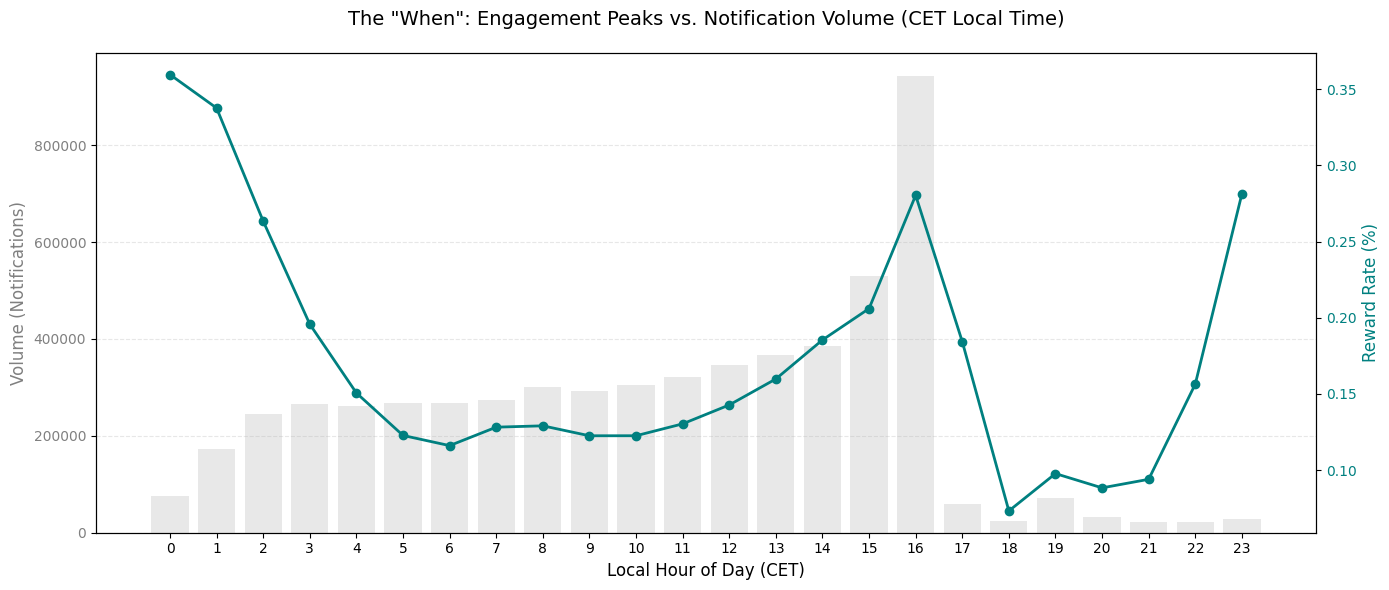

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# We focus on a specific timezone group (CET: de, it, pl, cs, hu)
# We apply a +1 offset for UTC to CET
cet_languages = ('de', 'it', 'pl', 'cs', 'hu')
timezone_offset = 1

df_temporal = con.execute("""
    WITH hourly_data AS (
        SELECT
            -- Convert the float datetime to a 24-hour block
            CAST(FLOOR((datetime - FLOOR(datetime)) * 24) AS INTEGER) AS utc_hour,
            session_end_completed
        FROM train
        WHERE ui_language IN (?, ?, ?, ?, ?)
    ),
    local_time AS (
        SELECT
            -- Shift UTC to Local Time (CET)
            ((utc_hour + ?) % 24) AS local_hour,
            session_end_completed
        FROM hourly_data
    )
    SELECT
        local_hour AS hour,
        COUNT(*) AS n_notifications,
        AVG(CASE WHEN session_end_completed THEN 1 ELSE 0 END) AS reward_rate
    FROM local_time
    GROUP BY 1
    ORDER BY 1
""", [*cet_languages, timezone_offset]).df()

# --- Visualization: Dual-Axis Chart ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# Axis 1: Bar chart for Volume (How many notifications Duolingo sends)
ax1.bar(df_temporal['hour'], df_temporal['n_notifications'], color='lightgray', alpha=0.5, label='Notification Volume')
ax1.set_xlabel('Local Hour of Day (CET)', fontsize=12)
ax1.set_ylabel('Volume (Notifications)', color='gray', fontsize=12)
ax1.tick_params(axis='y', labelcolor='gray')
ax1.set_xticks(range(0, 24))

# Axis 2: Line chart for Reward Rate (When users actually engage)
ax2 = ax1.twinx()
ax2.plot(df_temporal['hour'], df_temporal['reward_rate'], color='teal', marker='o', linewidth=2, label='Reward Rate')
ax2.set_ylabel('Reward Rate (%)', color='teal', fontsize=12)
ax2.tick_params(axis='y', labelcolor='teal')

plt.title('The "When": Engagement Peaks vs. Notification Volume (CET Local Time)', fontsize=14, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**3.2: Intraday Template Affinity (The "When" + "What")**

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

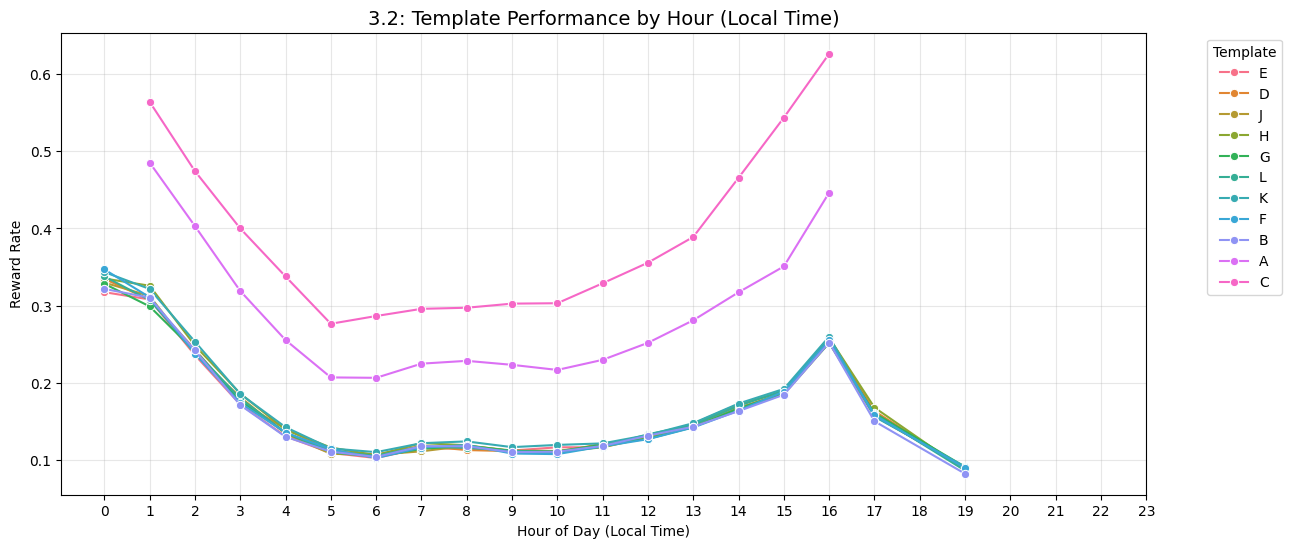

In [12]:
# Query to see if certain templates spike at specific hours (CET Local Time)
df_template_time = con.execute("""
    WITH base AS (
        SELECT
            CAST(FLOOR((datetime - FLOOR(datetime)) * 24) AS INTEGER) AS utc_hour,
            selected_template,
            session_end_completed
        FROM train
        WHERE ui_language IN ('de', 'it', 'pl', 'cs', 'hu')
    ),
    shifted AS (
        SELECT
            ((utc_hour + 1) % 24) AS local_hour,
            selected_template,
            session_end_completed
        FROM base
    )
    SELECT
        local_hour,
        selected_template,
        AVG(CASE WHEN session_end_completed THEN 1 ELSE 0 END) AS reward_rate,
        COUNT(*) as n
    FROM shifted
    GROUP BY 1, 2
    HAVING n > 5000 -- Filter for significant data
    ORDER BY 1
""").df()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_template_time, x='local_hour', y='reward_rate', hue='selected_template', marker='o')
plt.title('3.2: Template Performance by Hour (Local Time)', fontsize=14)
plt.xlabel('Hour of Day (Local Time)')
plt.ylabel('Reward Rate')
plt.xticks(range(0, 24))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Template')
plt.grid(True, alpha=0.3)
plt.show()

**Phase 4: The "Sleeping" Factor (Eligibility Constraints)**

**4.1 Eligibility vs. Template Performance**

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

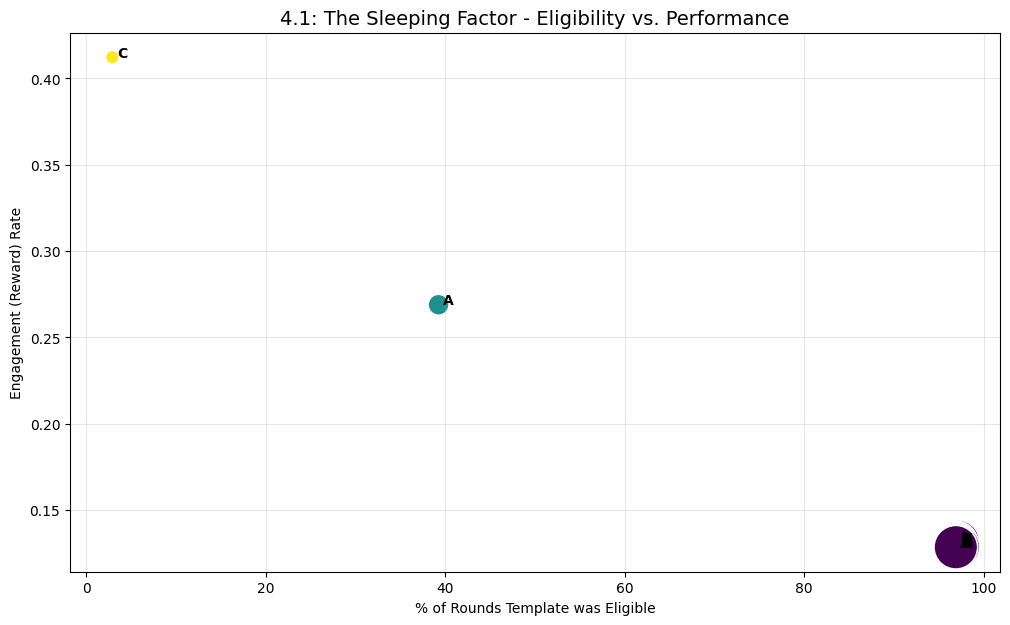

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate overall eligibility frequency and performance per template
df_sleeping = con.execute("""
    WITH unnested_eligibility AS (
        -- Isolate unnesting to a single step
        SELECT unnest(eligible_templates) as template
        FROM train
    ),
    eligibility_counts AS (
        -- Group by the result of the isolated unnest
        SELECT
            template,
            COUNT(*) as times_eligible
        FROM unnested_eligibility
        GROUP BY 1
    ),
    performance AS (
        SELECT
            selected_template as template,
            COUNT(*) as times_selected,
            AVG(CASE WHEN session_end_completed THEN 1 ELSE 0 END) AS reward_rate
        FROM train
        GROUP BY 1
    ),
    total_records AS (
        SELECT COUNT(*) as total_n FROM train
    )
    SELECT
        e.template,
        (e.times_eligible * 100.0 / (SELECT total_n FROM total_records)) AS percent_eligible,
        p.reward_rate,
        p.times_selected
    FROM eligibility_counts e
    JOIN performance p ON e.template = p.template
    ORDER BY reward_rate DESC
""").df()

# 2. Visualize Eligibility vs. Reward Rate
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_sleeping, x='percent_eligible', y='reward_rate', size='times_selected', sizes=(100, 1000), hue='reward_rate', palette='viridis', legend=False)

for i in range(df_sleeping.shape[0]):
    plt.text(x=df_sleeping.percent_eligible[i] + 0.5, y=df_sleeping.reward_rate[i], s=df_sleeping.template[i], fontweight='bold')

plt.title('4.1: The Sleeping Factor - Eligibility vs. Performance', fontsize=14)
plt.xlabel('% of Rounds Template was Eligible')
plt.ylabel('Engagement (Reward) Rate')
plt.grid(True, alpha=0.3)
plt.show()

**4.2: Choice Density (The System's Options)**

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

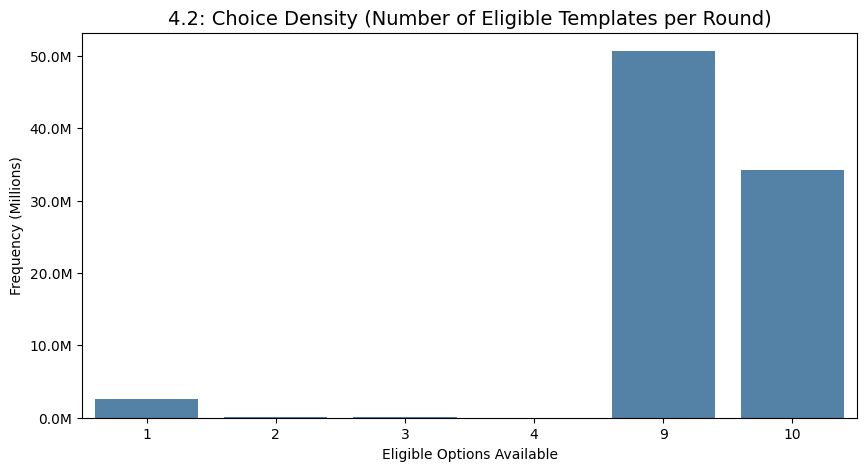

In [16]:
# Check how many templates are typically eligible per user decision
df_choices = con.execute("""
    SELECT
        ARRAY_LENGTH(eligible_templates) as num_options,
        COUNT(*) as n_rounds
    FROM train
    GROUP BY 1
    ORDER BY 1
""").df()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_choices, x='num_options', y='n_rounds', color='steelblue')
plt.title('4.2: Choice Density (Number of Eligible Templates per Round)', fontsize=14)
plt.xlabel('Eligible Options Available')
plt.ylabel('Frequency (Millions)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
plt.show()

**Phase 5: The "Recovering" Factor (Novelty & Memory)**

**5.1 Impact of Historical Score on Current Engagement**

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

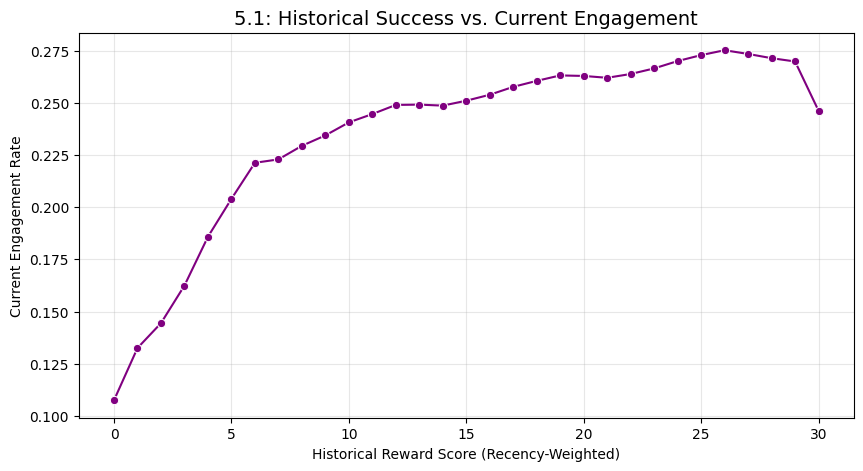

In [19]:
# 1. Query extracting the reward_value (n_days) from the history struct
df_recovery = con.execute("""
    WITH unnested_hist AS (
        SELECT
            session_end_completed,
            selected_template,
            unnest(history) as hist
        FROM train
        WHERE history IS NOT NULL
    ),
    matched_hist AS (
        SELECT
            session_end_completed,
            hist.n_days as historical_score -- n_days is the reward_value score
        FROM unnested_hist
        WHERE hist.template = selected_template
    )
    SELECT
        ROUND(historical_score) as score_bin,
        AVG(CASE WHEN session_end_completed THEN 1 ELSE 0 END) as reward_rate,
        COUNT(*) as n
    FROM matched_hist
    GROUP BY 1
    HAVING n > 5000
    ORDER BY 1
""").df()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_recovery, x='score_bin', y='reward_rate', marker='o', color='purple')
plt.title('5.1: Historical Success vs. Current Engagement', fontsize=14)
plt.xlabel('Historical Reward Score (Recency-Weighted)')
plt.ylabel('Current Engagement Rate')
plt.grid(True, alpha=0.3)
plt.show()

**5.2 Quantifying "Fatigue"**

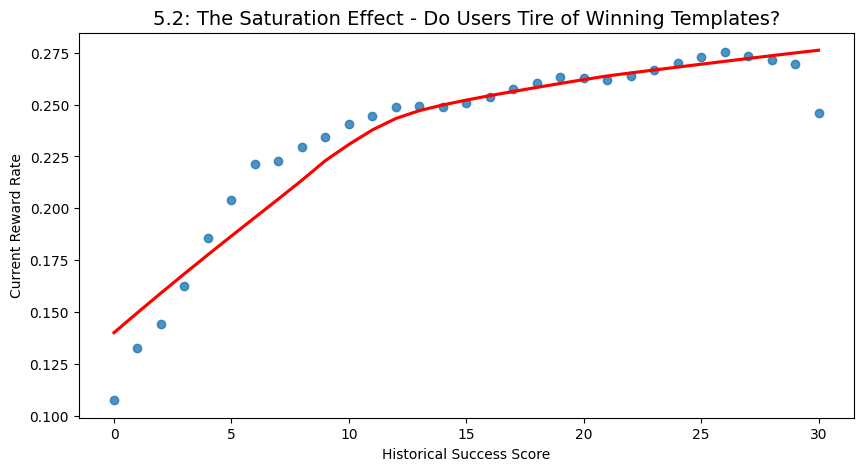

In [20]:
# Analyze engagement across the distribution of historical scores
plt.figure(figsize=(10, 5))
sns.regplot(data=df_recovery, x='score_bin', y='reward_rate', lowess=True, line_kws={'color':'red'})
plt.title('5.2: The Saturation Effect - Do Users Tire of Winning Templates?', fontsize=14)
plt.xlabel('Historical Success Score')
plt.ylabel('Current Reward Rate')
plt.show()

# Task
Synthesize the key findings from the EDA phases including global engagement rates, language-specific performance, temporal patterns, template eligibility, and historical impact into actionable insights and testable hypotheses to answer: 'How to motivate people to practice?', 'What should the notification say?', and 'When should they send it?'.

## Summarize Current Analysis

### Subtask:
Synthesize key findings from the EDA phases, including global engagement rates, language-specific performance, temporal patterns, template eligibility, and historical impact, to address the core questions.


### Key Findings from EDA Phases:

**1. Global Engagement Rates & Class Imbalance (Phase 1)**
- The global reward rate (session end completed) is **14.38%**, indicating that for every 100 notifications sent, approximately 14 result in a completed session.
- There is a significant class imbalance, with **75.06 million negative interactions (ignored)** compared to **12.61 million positive interactions (engaged)**. This imbalance highlights the challenge of predicting positive engagement.

**2. Language Distribution (Phase 2)**
- **English (en)**, **Spanish (es)**, and **Portuguese (pt)** are the top three UI languages by notification volume, accounting for a large majority of interactions. English alone has over 35 million notifications.

**3. Language vs. Template Affinity (Phase 2)**
- Template performance varies significantly across languages. For example, Template 'C' consistently shows a much higher reward rate (e.g., 43.6% in English, 37.9% in Spanish) compared to other templates within the same language.
- Some templates (e.g., 'A') perform reasonably well across multiple languages, while others show more language-specific performance.

**4. Temporal Patterns - The "When" (Phase 3)**
- In the CET timezone (e.g., German, Italian, Polish), notification volume is relatively stable throughout the day, peaking slightly during daytime hours.
- However, the reward rate exhibits a strong temporal pattern: it is highest during early morning hours (e.g., 0-2 AM CET, ~35-33%) and lowest during late morning/early afternoon (e.g., 6-10 AM CET, ~11-12%). This suggests a mismatch between when notifications are sent and when users are most receptive.

**5. Intraday Template Affinity (Phase 3)**
- The performance of individual templates also varies by the hour of the day. Some templates maintain relatively stable reward rates, while others show distinct peaks or troughs at specific hours, further emphasizing the importance of contextual timing for template selection.

**6. Eligibility Constraints - The "Sleeping" Factor (Phase 4)**
- Templates like 'C', which have a very high reward rate (~41.2%), are eligible in a relatively small percentage of rounds (~2.88%). This suggests they might be "sleeping giants" with high potential if offered more frequently.

**7. Choice Density (Phase 4)**
- The system most frequently offers **9 or 10 eligible templates** per decision round, indicating a rich choice space for the MAB algorithm.
- There's a notable difference in reward rates based on the number of available choices, with 1 option having a high reward rate (0.41) but rarely occurring, and 9/10 options having reward rates around 0.046 and 0.267 respectively.

**8. Historical Success vs. Current Engagement (Phase 5)**
- There's a clear positive correlation between historical reward score (n_days) and current engagement. Templates with higher historical scores (meaning more recent past success) tend to have higher current reward rates.
- This suggests that users are more likely to engage with templates they have successfully completed recently.

**9. The Saturation Effect / Fatigue (Phase 5)**
- While historical success generally leads to higher engagement, the regression plot shows a flattening or slight diminishing return at very high historical scores. This indicates a potential "fatigue" or saturation point where repeatedly successful templates might start to see a decline in engagement, highlighting the need for novelty or rotation.

## Formulate Hypotheses

### Subtask:
Propose testable hypotheses based on the identified insights, outlining potential directions for motivating users, optimizing notification content, and determining the best sending times.


## Formulate Hypotheses

Based on the initial EDA findings, we can propose several testable hypotheses to guide further experimentation and optimization. These hypotheses address the core questions of motivating users, optimizing notification content, and determining optimal sending times.

### 1. How to motivate people to practice?

*   **Hypothesis 1.1 (Leveraging High-Performing Templates):** Users will exhibit higher engagement (reward rate) when exposed to templates identified as high-performing overall (e.g., Template C, which showed a significantly higher global reward rate of 41.2%) compared to average-performing templates.

*   **Hypothesis 1.2 (Personalization based on Historical Success):** Personalizing template selection to prioritize templates with which a user has a higher `historical_score` (recency-weighted) will lead to an increased current engagement rate, as users tend to engage more with templates they have successfully completed recently.

*   **Hypothesis 1.3 (Combating Fatigue/Introducing Novelty):** Introducing templates with which a user has a lower `historical_score` (or has not interacted with recently) for users showing signs of 'fatigue' with frequently used high-score templates, will lead to an increase in engagement by leveraging novelty.

### 2. What should the notification say?

*   **Hypothesis 2.1 (Content Characteristics of High-Performing Templates):** Notifications that replicate the underlying structural or linguistic characteristics (e.g., tone, call-to-action, conciseness) of consistently high-performing templates (like Template C) will result in higher engagement rates.

*   **Hypothesis 2.2 (Language-Specific Tailoring):** Customizing notification content based on the `ui_language` and its observed template affinities (e.g., using Template C for English users where it performs best) will yield higher reward rates compared to a universal content strategy, as different linguistic groups show varying preferences.

*   **Hypothesis 2.3 (Contextual Messaging):** Messages that acknowledge a user's recent successful interactions (`historical_score` > threshold) by providing positive reinforcement or, conversely, offering a 'fresh start' when fatigue is detected, will lead to improved engagement.

### 3. When should they send it?

*   **Hypothesis 3.1 (Optimizing for Peak Reward Rate Times):** Sending notifications during early morning local hours (e.g., 0-3 AM Local Time for CET languages, which show peak reward rates above 30%) will result in higher engagement compared to sending during periods of high notification volume but lower reward rates (e.g., 5-10 AM Local Time).

*   **Hypothesis 3.2 (Dynamic Intraday Template Performance Adjustment):** Dynamically adjusting the selected template based on its observed intraday performance patterns (e.g., using a template that performs exceptionally well at 8 AM local time) will lead to an overall higher reward rate than using a static template selection strategy throughout the day.

## Final Task

### Subtask:
Provide a comprehensive overview of the insights and hypotheses generated from the analysis to answer: 'How to motivate people to practice?', 'What should the notification say?', and 'When should they send it?'


## Summary:

### Q&A

*   **How to motivate people to practice?**
    Users are more motivated by templates that have historically performed well globally (e.g., Template C) and when templates are personalized based on their recent successful engagements. Introducing novelty or less frequently used templates can also combat fatigue and boost motivation.
*   **What should the notification say?**
    Notifications should emulate the structural and linguistic characteristics of consistently high-performing templates. Content should be tailored to the user's UI language, leveraging observed template affinities. Contextual messages, such as positive reinforcement for recent successes or 'fresh start' prompts for fatigued users, are also hypothesized to improve engagement.
*   **When should they send it?**
    Sending notifications during early morning local hours (e.g., 0-3 AM Local Time for CET languages) is hypothesized to result in higher engagement due to observed peak reward rates. Additionally, dynamically adjusting the chosen template based on its performance variations throughout the day is expected to optimize overall reward rates.

### Data Analysis Key Findings

*   The global reward rate (session completion) is low, at **14.38%**, indicating that only about 14 out of 100 notifications lead to a completed session. This is coupled with a significant class imbalance of **75.06 million ignored interactions** versus **12.61 million engaged interactions**.
*   **English (en)**, **Spanish (es)**, and **Portuguese (pt)** are the dominant UI languages by notification volume, with English alone accounting for over 35 million notifications.
*   Template performance varies substantially across languages; for example, Template 'C' exhibits a high reward rate (e.g., **43.6% in English, 37.9% in Spanish**), outperforming other templates within the same language.
*   Reward rates show strong temporal patterns, being highest during early morning hours (e.g., **0-2 AM CET, ~35-33%**) and lowest during late morning/early afternoon (e.g., **6-10 AM CET, ~11-12%**), despite notification volume remaining relatively stable.
*   Templates with high reward rates, such as Template 'C' (**~41.2%**), are eligible in only a small percentage of rounds (**~2.88%**), suggesting they are underutilized.
*   There is a positive correlation between a template's historical reward score and current engagement, meaning users are more likely to engage with templates they have successfully completed recently.
*   A saturation effect is observed, where very high historical scores show a flattening or slight diminishing return in engagement, suggesting potential user fatigue.

### Insights or Next Steps

*   **Prioritize High-Performing, Underutilized Templates:** Experiment with increasing the eligibility and frequency of high-reward templates like 'C' across relevant languages and time slots, as they appear to be "sleeping giants."
*   **Optimize Notification Timing and Content based on Temporal and Language Patterns:** Test sending notifications during peak reward rate hours (e.g., early morning local time) and tailor template selection and content based on language-specific affinities and intraday performance variations to maximize engagement.
